# House Price Prediction System
Machine Learning project to predict house prices using regression models.

# import Libraries

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

import joblib



# Load Datasets

In [140]:
df = pd.read_csv('data.csv')
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [142]:
df.shape

(4600, 18)

In [143]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


# Data Cleaning

In [144]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
df['statezip'].nunique()

77

In [147]:
df.drop(['street', 'country'], axis = 1, inplace = True)

In [148]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.drop('date', axis = 1, inplace = True)

In [149]:
df = pd.get_dummies(df, columns = ['city'], drop_first = True)

In [150]:
df['zipcode'] = df['statezip'].str.extract(r'(\d+)').astype(int)

In [151]:
df.drop('statezip', axis = 1, inplace = True)

# EDA and Feature Engineering

In [152]:
df['house_age'] = df['year'] - df['yr_built']

df['total_rooms'] = df['bedrooms'] + df['bathrooms']

df['total_sqft'] = df['sqft_living'] + df['sqft_basement']

In [153]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

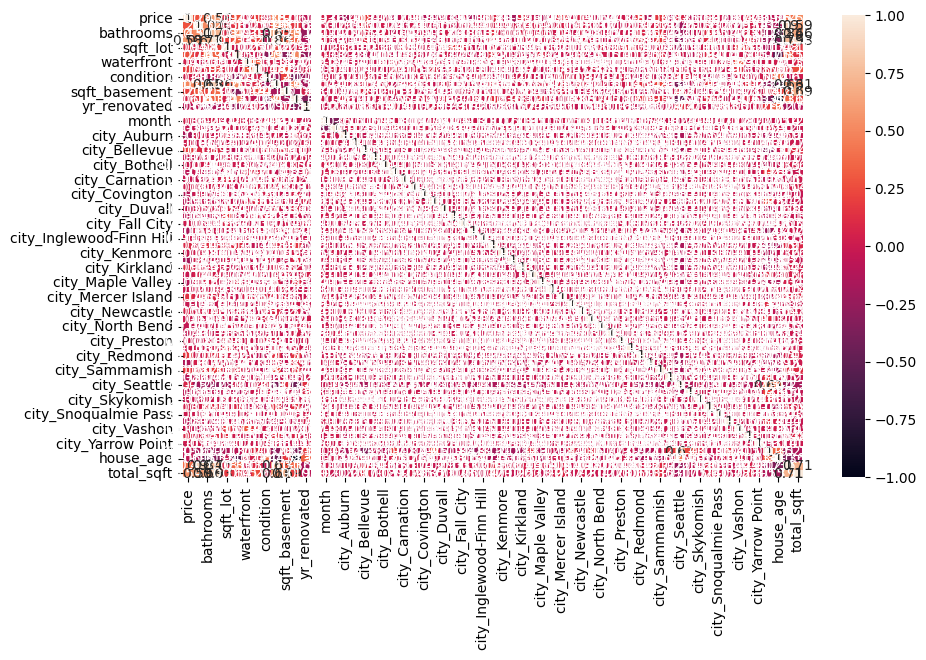

In [154]:
plt.figure(figsize = (10, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True, )
plt.show()

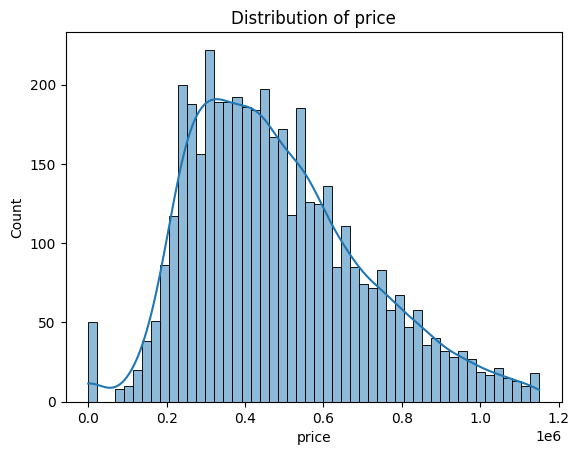

In [155]:
sns.histplot(df['price'], bins = 50, kde = True)
plt.title('Distribution of price')
plt.show()

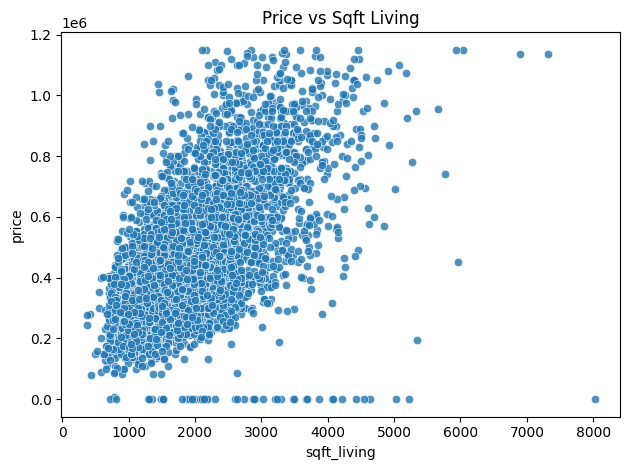

In [156]:
sns.scatterplot(x = 'sqft_living', y = 'price',alpha = 0.8, data = df)
plt.title('Price vs Sqft Living')
plt.tight_layout()
plt.show()

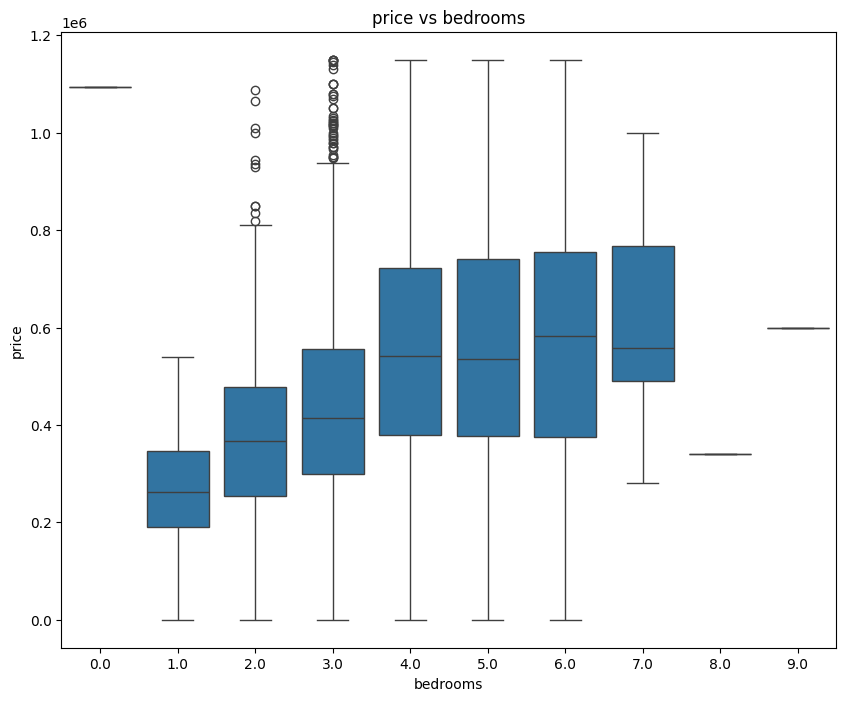

In [157]:
plt.figure(figsize = (10, 8))
sns.boxplot(x = 'bedrooms', y = 'price', data = df)
plt.title('price vs bedrooms')
plt.show()

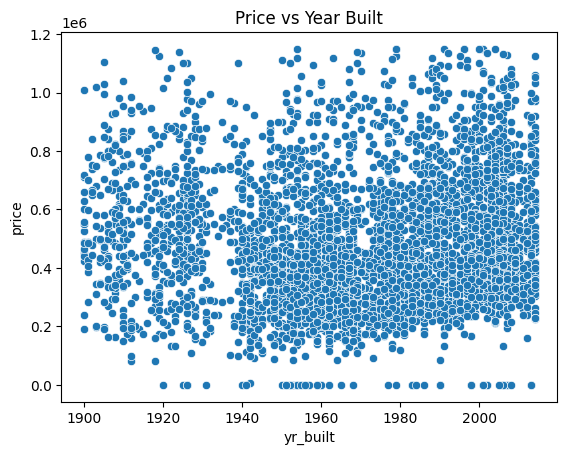

In [158]:
sns.scatterplot(x = 'yr_built', y = 'price', alpha = 1, data = df)
plt.title("Price vs Year Built")
plt.show()

In [159]:
X = df.drop('price', axis = 1)
y = df['price']

# Train test split

In [160]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Feature Scaling

In [161]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

Linear Regression

In [162]:

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
pred_lr = lr_model.predict(X_test_scaled)

In [163]:
pred_lr

array([ 580078.11063207,  572913.11810758,  545537.10502584,
        395166.55121379,  537796.77022401,  419145.93805614,
        489674.38916679,  424928.32938131,  484978.53565752,
        286653.59483271,  415454.90724533,  579189.1078627 ,
        283048.90325717,  437446.79095378,  425731.96089524,
        534246.69032261,  386427.73441616,  404133.0126156 ,
        278640.70335936,  630328.74719439,  339340.74512026,
        378915.82700564,  537736.6046407 ,  144316.84727699,
        706090.71944702,  452012.91903373,  180707.50228582,
        402370.48410336,  425969.41953798,  373348.69461214,
        597410.41948475,  239704.58710653,  242673.96797323,
        955271.02700678,  617657.05510861,  692314.49200018,
        230581.83736996,  633672.88253656,  413506.26195754,
        850520.67474261,  482068.72396278,  521647.6636762 ,
        483527.20096192,  443617.74907187,  200252.9620627 ,
        331685.64458817,  485315.33572333,  404359.39066319,
        509691.98694977,

Random Forest

In [164]:

rf  = RandomForestRegressor( n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [165]:
pred_rf

array([683933.41272467, 534102.12912696, 572117.51524269, 338899.11509358,
       415433.31218055, 386386.34567672, 529284.59846928, 389677.36505097,
       415716.94313216, 377581.24028698, 436490.46683027, 628845.76117837,
       284612.73279291, 431953.44993393, 520192.44961092, 457131.7741832 ,
       380029.83540226, 428222.82979281, 349639.70688342, 609311.16565864,
       379960.22583565, 401441.68064917, 450891.65932732, 265459.3254232 ,
       666683.28873797, 412182.68061213, 342907.27738022, 429876.80681512,
       427331.7321878 , 308409.52505453, 669086.24394122, 417243.88255818,
       337339.89703981, 759676.64674688, 529783.35992502, 613662.07623947,
       337863.3912909 , 592056.49714483, 452671.35012429, 710344.37677332,
       451093.78238079, 503962.58023755, 486481.32248769, 358769.79183118,
       260197.38801192, 270989.68338215, 386588.65546569, 392965.13067047,
       470932.56874304, 753442.06692181, 286432.08982024, 463158.81161876,
       311504.06362928, 3

# Feature importance

In [166]:
importance = rf.feature_importances_

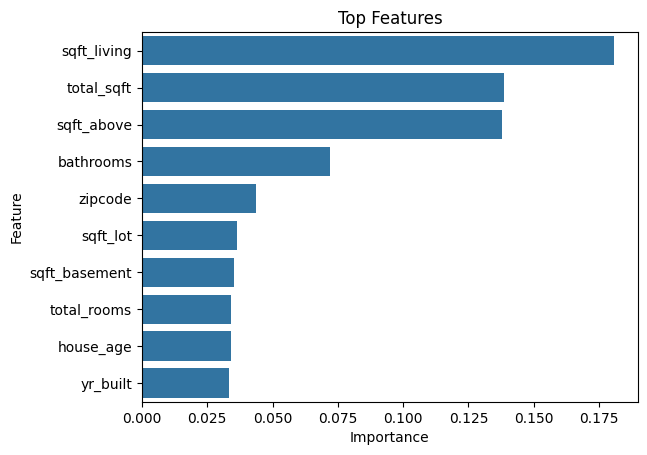

In [167]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top Features')
plt.show()

Gradient Boosting

In [168]:

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

In [169]:
pred_gb

array([691544.80082687, 578294.24534917, 579045.67487869, 355501.00949329,
       467513.208243  , 427522.36231689, 501214.65588394, 388184.00836744,
       425269.67711277, 319440.19333223, 393424.73441002, 651504.98680156,
       241420.31599782, 463758.44855961, 442303.04379691, 668918.17706403,
       386087.89776777, 439221.11273663, 311497.09329251, 655898.34860116,
       307941.86934269, 392463.78524955, 462465.43490279, 202742.1533488 ,
       684044.40003274, 470130.09746324, 263942.50544816, 445427.47834057,
       459230.76485925, 294947.09475363, 654777.17541741, 349950.41712102,
       297166.29344994, 951750.67741827, 531171.8845979 , 630894.73372076,
       266354.703951  , 620864.61039791, 388723.40769042, 747056.60573509,
       439004.52531044, 484718.32380071, 469006.75693887, 400783.89693255,
       244493.61093532, 298813.05352011, 411295.14477834, 403524.25143727,
       522570.44122764, 781674.18566622, 258217.25218471, 481273.59995463,
       262460.20083982, 4

XGBoost

In [170]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [171]:
pred_xgb

array([5.87483250e+05, 5.28682125e+05, 6.27608375e+05, 3.36240875e+05,
       4.57896188e+05, 3.04276031e+05, 5.02576594e+05, 3.84977625e+05,
       4.48459188e+05, 3.02849531e+05, 4.23904250e+05, 7.27163688e+05,
       2.72134156e+05, 4.71609094e+05, 3.62003000e+05, 8.61400000e+05,
       3.27951094e+05, 3.15254844e+05, 2.31975875e+05, 5.90183750e+05,
       2.88454719e+05, 2.84285938e+05, 5.22560750e+05, 1.95481031e+05,
       7.25616938e+05, 4.91117375e+05, 2.22714047e+05, 4.69946094e+05,
       4.92775531e+05, 2.81920375e+05, 5.68276625e+05, 1.81231922e+05,
       2.88006500e+05, 1.06207662e+06, 5.84480250e+05, 6.61598125e+05,
       2.58676594e+05, 6.08998812e+05, 3.82622312e+05, 7.28565000e+05,
       4.20073625e+05, 5.93148750e+05, 3.07954031e+05, 3.74524000e+05,
       2.24733625e+05, 1.81738047e+05, 3.96100719e+05, 4.75060812e+05,
       5.44518312e+05, 7.63339875e+05, 2.79100000e+05, 5.73771250e+05,
       2.13826250e+05, 4.33532938e+05, 7.39197812e+05, 5.62499625e+05,
      

# Evaluation for Linear Regressiom

In [172]:
print(mean_absolute_error(y_test, pred_lr))
print(mean_squared_error(y_test, pred_lr))
print(r2_score(y_test, pred_lr))

93553.85280128846
19809944906.556488
0.6001835645127429


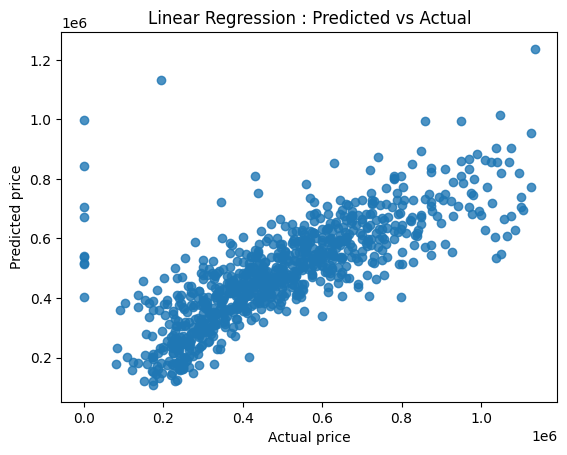

In [173]:
plt.scatter(y_test, pred_lr, alpha = 0.8)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Linear Regression : Predicted vs Actual')
plt.show()

# Evaluation for randomforest

In [174]:
print(mean_absolute_error(y_test, pred_rf))
print(mean_squared_error(y_test, pred_rf))
print(r2_score(y_test, pred_rf))

109110.78336636181
22814591364.530426
0.5395419502935658


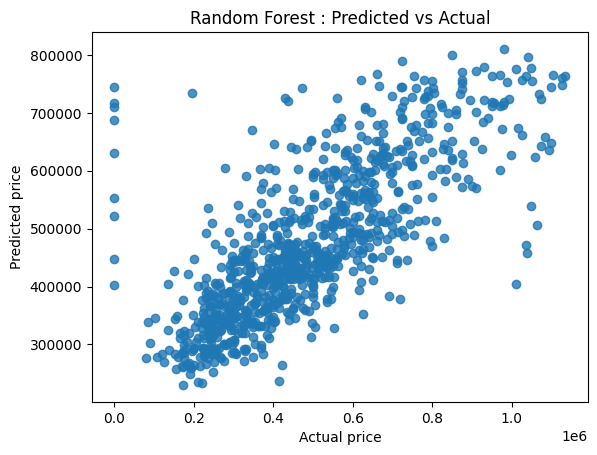

In [175]:
plt.scatter(y_test, pred_rf, alpha = 0.8)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Random Forest : Predicted vs Actual')
plt.show()

# Evaluation for Gradient Boosting

In [176]:
print(mean_absolute_error(y_test, pred_gb))
print(mean_squared_error(y_test, pred_gb))
print(r2_score(y_test, pred_gb))

91304.4898327251
17823468244.534016
0.6402758526001059


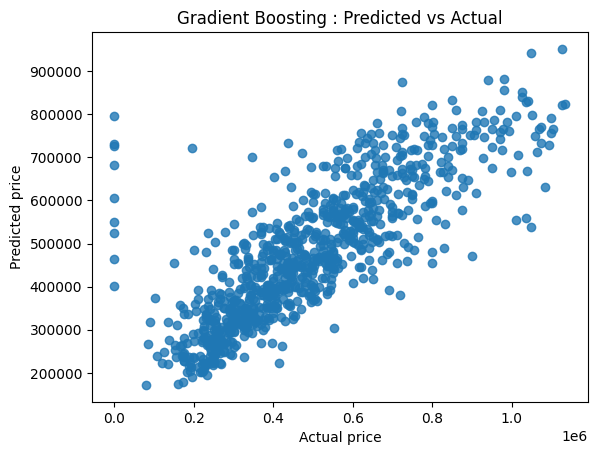

In [177]:
plt.scatter(y_test, pred_gb, alpha = 0.8)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Gradient Boosting : Predicted vs Actual')
plt.show()

# Evaluation for XGBoost

In [178]:
print(mean_absolute_error(y_test, pred_xgb))
print(mean_squared_error(y_test, pred_xgb))
print(r2_score(y_test, pred_xgb))

80130.95439944611
14841744607.553257
0.7004548244129545


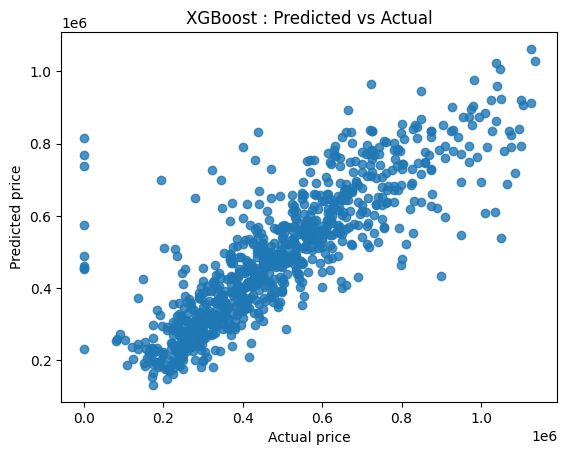

In [179]:
plt.scatter(y_test, pred_xgb, alpha = 0.8)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('XGBoost : Predicted vs Actual')
plt.show()

In [180]:
corr = df.corr(numeric_only=True)['price'].sort_values(ascending=False)

print(corr)

price               1.000000
sqft_living         0.579565
total_sqft          0.535317
sqft_above          0.500765
bathrooms           0.434377
                      ...   
city_Renton        -0.127743
city_Federal Way   -0.163306
city_Auburn        -0.169888
city_Kent          -0.175748
year                     NaN
Name: price, Length: 63, dtype: float64


# Cross Validation

In [181]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.61662543 0.58436435 0.60564948 0.59574675 0.27917216]
0.5363116339089794


In [182]:
scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.63661766 0.65716099 0.70806816 0.67010518 0.08488062]
0.5513665228333482


In [183]:
scores = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.61012886 0.66974283 0.71441186 0.64348985 0.28850061]
0.5852548029224878


In [184]:
scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.49316268 0.6761515  0.71741386 0.5989471  0.28240877]
0.5536167811121805


# Model Comparison Table

In [185]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb),
        r2_score(y_test, pred_xgb)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.600184
1,Random Forest,0.539542
2,Gradient Boosting,0.640276
3,XGBoost,0.700455


In [186]:
joblib.dump(rf, 'house_price_model.pkl')

['house_price_model.pkl']

# Conclusion

- Random Forest performed better than Linear Regression.
- Feature engineering improved performance.
- Location and square footage highly influenced house prices.
- Cross-validation showed stable performance.